# This report concerns the relationship between sleep and the allocation of time.

- In their article, Biddle and Hamermesh study sleep as an economic choice affected primarly by work, wages, and individual characteristics.

- The key idea is that higher wage rates may reduce sleep time among men, because a higher wage increases the opportunity cost of time spent sleeping. However, the wage variable creates an econometric problem; it is missing for individuals who do not work and may also be endogenous.

- The aim of this report is to examine and estimate a statistical model for sleep time as well as the limitations caused by missing wage data and possible endogeneity.

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [31]:
column_names = [
    "age_years",
    "is_black",
    "case_id",
    "is_clerical_worker",
    "is_construction_worker",
    "education_years",
    "earnings_1974",
    "good_health",
    "in_labor_force",
    "leisure_excl_naps",
    "leisure_incl_naps",
    "leisure_relaxation",
    "lives_in_smsa",
    "log_hourly_wage",
    "log_other_income",
    "is_male",
    "is_married",
    "is_protestant",
    "relaxation_total",
    "is_self_employed",
    "sleep_minutes",
    "sleep_naps_minutes",
    "lives_in_south",
    "spouse_wage_income",
    "spouse_works",
    "work_minutes",
    "union_member",
    "main_job_minutes",
    "second_job_minutes",
    "experience_years",
    "has_young_child",
    "years_married",
    "hourly_wage",
    "age_squared",
]

# note: I'm using modified column names, not the exact names from the dataset description file, for improved readability

df = pd.read_excel("sleep75.xls", header=None, names=column_names, na_values=".")


print(df.head(5))
print(df.shape)
print(df.info())
print(df.describe())

   age_years  is_black  case_id  is_clerical_worker  is_construction_worker  \
0         32         0        1                 0.0                     0.0   
1         31         0        2                 0.0                     0.0   
2         44         0        3                 0.0                     0.0   
3         30         0        4                 0.0                     0.0   
4         64         0        5                 0.0                     0.0   

   education_years  earnings_1974  good_health  in_labor_force  \
0               12              0            0               1   
1               14           9500            1               1   
2               17          42500            1               1   
3               12          42500            1               1   
4               14           2500            1               1   

   leisure_excl_naps  ...  spouse_works  work_minutes  union_member  \
0               3529  ...             0          3438    

In [32]:
print(df.isna().sum())

print(df["hourly_wage"].isna().sum())

print(df[df["in_labor_force"] == 0].isna().sum().sum() / 2)

# This is a check for IF the missing values are for sure only happening in people not in the labor force.

age_years                   0
is_black                    0
case_id                     0
is_clerical_worker          0
is_construction_worker      0
education_years             0
earnings_1974               0
good_health                 0
in_labor_force              0
leisure_excl_naps           0
leisure_incl_naps           0
leisure_relaxation          0
lives_in_smsa               0
log_hourly_wage           174
log_other_income            0
is_male                     0
is_married                  0
is_protestant               0
relaxation_total            0
is_self_employed            0
sleep_minutes               0
sleep_naps_minutes          0
lives_in_south              0
spouse_wage_income          0
spouse_works                0
work_minutes                0
union_member                0
main_job_minutes            0
second_job_minutes          0
experience_years            0
has_young_child             0
years_married               0
hourly_wage               174
age_square

Overall, we can observe as much as 174 missing values all concerning hourly wages.

This will be our main concern in modelling this dataset, because wage is not missing at random.

The missing values are **only** spread among individuals who are not in the labor force.

This confirms that wage missingness is missing **not** at random

Hence, I decide not use simple median imputation for wage, for the reason that data is missing for a systematic economic reason, not because of random measurement failure. 

Imputing the average or median wage for nonworkers would create artificial wage values and would blur the distinction between workers and nonworkers.

Therefore, dropping all observations with missing wage would remove nonworkers from the sample and change the analysis from the full population to labor force participants only.

For this reason, I'm going to use two separate models;

The main model will be estimated on the full sample and will exclude wage, while including an indicator for labor-force participation.

The second model will be estimated only for individuals in the labor force and will include hourly wage (or its logarithm).
This model will be treated as a secondary specification, useful for examining the wage and sleep relationship among workers only.

Though I'm obliged to mention that its results will not describe the full sample.

# First, manual analysis of the dataset

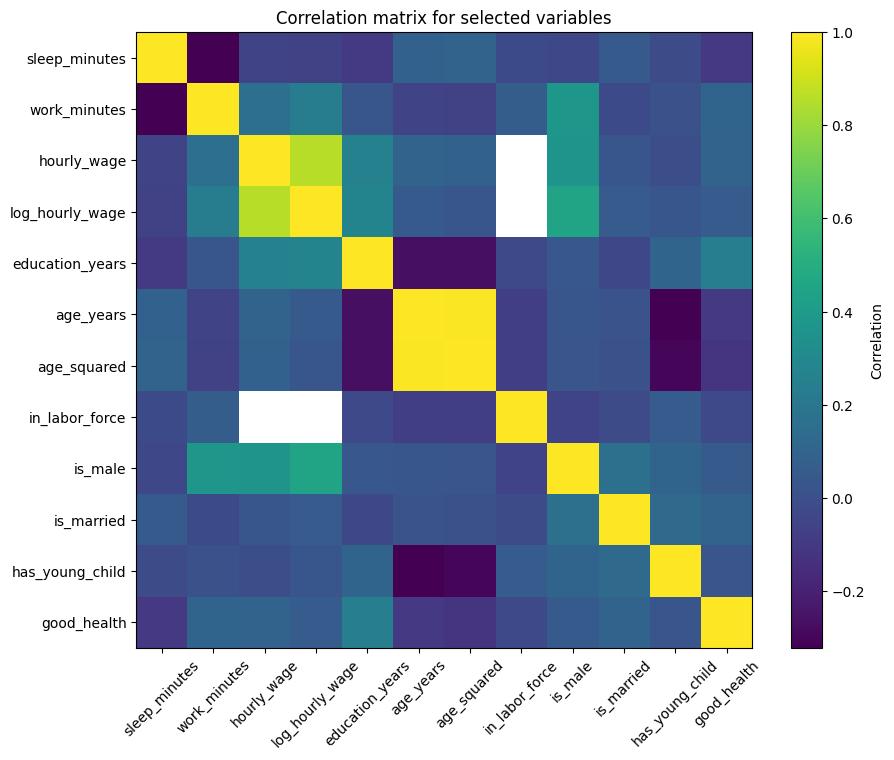

In [43]:
main_variables = [
    "sleep_minutes",
    "work_minutes",
    "hourly_wage",
    "log_hourly_wage",
    "education_years",
    "age_years",
    "age_squared",
    "in_labor_force",
    "is_male",
    "is_married",
    "has_young_child",
    "good_health"
]

df[main_variables].describe().T

corr_with_sleep = (
    df[main_variables]
    .corr(numeric_only=True)["sleep_minutes"]
    .sort_values(key=abs, ascending=False)
)

corr_matrix = df[main_variables].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation matrix for selected variables")
plt.show()